In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import re

In [2]:
# GLOBAL VARIABLES

#directories and paths
DATASET_CSV_PATH = "data/sample_dataset_csv"
DATASET_PATH = "data/sample_dataset"
LOGS_DIR = "logs"
SCENARIO_SEP = "-generated"
LOG_CCI = "component_container_isolated"


#NAMES COLUMNS
TIMESTAMP = 'timestamp'
TOPIC = 'topic'
TYPE = 'type'
POSE_FROM_COV = "pose.pose."
POSITION_X = "position.x"
POSITION_Y = "position.y"
ORIENTATION_Z = 'orientation.z'
ORIENTATION_W = 'orientation.w'
COVARIANCE = "pose.covariance"

#TOPICS
AMCL_POSE = '/amcl_pose'
GROUNDTRUTH_POSE = '/groundtruth_pose'

#LOGS MSG IDENTIFIERS
LOGS_SUCCESS = 'Goal succeeded'
LOGS_FAILED = 'Goal failed'
LOGS_BEGIN = 'Begin navigating'
LOGS_NEW_PATH = 'Passing new path to controller.'
LOGS_PROGRESS_F = 'Failed to make progress'
LOGS_PLAN_F = 'GridBased plugin failed to plan'

In [3]:
#Objects

# Class with the data of a ros iteration in a scenario
class DatasetRos:
    def __init__(self, scenario, run_n, csv_file):
        self.scenario = scenario
        self.run_n = run_n
        self.csv_file = csv_file
        self.df = pd.read_csv(
            csv_file,
            comment='#',       
            sep=',',           
            quotechar='"',     
            engine='python'
        )
        self.logs_success = []     # Goal succeeded
        self.logs_failed = []      # Goal failed
        self.logs_begin = []       # Begin navigating
        self.logs_new_path = []    # Passing new path to controller.
        self.logs_progress_f = []  # Failed to make progress
        self.logs_plan_f = []      # GridBased plugin failed to plan

    def add_log(self, log):
        if LOGS_SUCCESS in log.msg:
            self.logs_success.append(log)
        elif LOGS_FAILED in log.msg:
            self.logs_failed.append(log)
        elif LOGS_BEGIN in log.msg:
            self.logs_begin.append(log)
        elif LOGS_NEW_PATH in log.msg:
            self.logs_new_path.append(log)
        elif LOGS_PROGRESS_F in log.msg:
            self.logs_progress_f.append(log)
        elif LOGS_PLAN_F in log.msg:
            self.logs_plan_f.append(log)
#Class for the logs of ros
class LogsRos:
    def __init__(self, type_msg, time, sender, msg):
        self.type = type_msg
        self.time = time
        self.sender = sender
        self.msg = msg

In [4]:
#Functions

#Quaternion for 2D orentation to yaw
def quaternion_to_yaw(z, w):
    return np.arctan2(2*w*z, 1 - 2*z**2)

# Get Pose error of the scenario (2D) in form of position_error, yaw_error, timestamp
# given deduced pose info and real pose info
def get_pose_error(deduced_pose, real_pose):
    #since is 2D just take position.x and y and orientation.z and w.
    deduced_position_x = deduced_pose[POSE_FROM_COV + POSITION_X].to_numpy()
    deduced_position_y = deduced_pose[POSE_FROM_COV + POSITION_Y].to_numpy()
    deduced_orientation_z = deduced_pose[POSE_FROM_COV + ORIENTATION_Z].to_numpy()
    deduced_orientation_w = deduced_pose[POSE_FROM_COV + ORIENTATION_W].to_numpy()
    deduced_timestamp = deduced_pose[TIMESTAMP].to_numpy()

    real_position_x = real_pose[POSITION_X].to_numpy()
    real_position_y = real_pose[POSITION_Y].to_numpy()
    real_orientation_z = real_pose[ORIENTATION_Z].to_numpy()
    real_orientation_w = real_pose[ORIENTATION_W].to_numpy()
    real_timestamp = real_pose[TIMESTAMP].to_numpy()
    
    #get interpolation of real_pose to timestamp of deduced_pose.
    real_position_x_inter = np.interp(deduced_timestamp, real_timestamp, real_position_x)
    real_position_y_inter = np.interp(deduced_timestamp, real_timestamp, real_position_y)
    real_orientation_z_inter = np.interp(deduced_timestamp, real_timestamp, real_orientation_z)
    real_orientation_w_inter = np.interp(deduced_timestamp, real_timestamp, real_orientation_w)

    #now it is possible to get the vectoriced error
    dx = deduced_position_x - real_position_x_inter
    dy = deduced_position_y - real_position_y_inter
    position_error = np.sqrt(dx**2 + dy**2)
    
    #get yaw error.
    real_yaw_inter = quaternion_to_yaw(real_orientation_z_inter, real_orientation_w_inter)
    deduced_yaw = quaternion_to_yaw(deduced_orientation_z, deduced_orientation_w)
    yaw_error = deduced_yaw - real_yaw_inter
    #normalice between [-pi, pi]
    yaw_error = (yaw_error + np.pi) % (2 * np.pi) - np.pi

    return position_error, yaw_error, deduced_timestamp

# Get dispersion of the position and orientation (2D) and  from deduced pose rows in form disp_pos, disp_yaw, timestamp
def get_disp_covariance(deduced_pose):
    disp_poss = []
    disp_yaws = []
    covariances_str = deduced_pose[COVARIANCE].to_numpy()
    timestamp = deduced_pose[TIMESTAMP].to_numpy()
    
    for covariance_str in covariances_str:
        #get the matrix from the string
        covariance = np.fromstring(covariance_str.replace('\n', ' ').replace('[', '').replace(']', ''), sep=' ')
        size = int(np.sqrt(len(covariance)))
        cov_matrix = covariance.reshape(size, size)
        
        disp_pos = np.linalg.det(cov_matrix[:2, :2])
        disp_yaw = cov_matrix[5,5]
        
        disp_poss.append(disp_pos)
        disp_yaws.append(disp_yaw)
    return disp_poss, disp_yaws, timestamp

cmap = plt.get_cmap('tab10')

# Localization Analysis

## Introduction

This analysis focuses on evaluating the performance of the robot localization system using data obtained from several simulation scenarios.  
For each scenario and run, the real position and orientation of the robot are compared to the estimated ones provided by the **Nav2 localization module**, which relies on LiDAR-based 2D pose estimation in ROS2.

The objective is to understand the behavior of the localization system, identify possible sources of error, and analyze the consistency and accuracy of the estimated pose throughout the robot’s trajectory.

---

## Methodology

For every scenario, the CSV files are processed to extract:

- **Real position and orientation** of the robot.
- **Estimated position and orientation** from Nav2 (based on LiDAR and the map).
- **Covariance matrix** associated with the estimated pose.

From these data, the following metrics are computed:

1. **Vectorial position error**:  
   The Euclidean distance between the real and estimated positions at each timestamp.

2. **Orientation error**:  
   The angular difference between the real and estimated yaw angles.

3. **Dispersion (Uncertainty)**:  
   - For position: the determinant of the top-left 2×2 submatrix of the covariance matrix (`[0:2, 0:2]`), which reflects the uncertainty in the estimated (x, y) position.  
   - For orientation: the variance of the yaw angle, given by element `[5,5]` of the covariance matrix.

Each scenario is analyzed independently, focusing on how the position and orientation errors evolve over time and how they relate to the estimated dispersion.  

Finally, the behavior across scenarios is compared, although this comparison provides limited insight due to the high scenario-specific nature of localization uncertainty.

---

## Data Preprocessing Steps
1. Load CSV logs (amcl_pose, groundtruth_pose, tf, etc.) using Pandas.
2. Clean data: remove missing timestamps, align AMCL and ground truth messages by closest timestamp.
3. Compute position/orientation error and covariance determinants.
4. Aggregate data per scenario and run.
5. Visualize temporal evolution of error and dispersion.

In [5]:
#Get csv dataset 
dataset = []

for csv_file in os.listdir(DATASET_CSV_PATH):
    if csv_file.endswith(".csv"):
        full_path = os.path.join(DATASET_CSV_PATH, csv_file)
        #Get map_name and run
        name = csv_file[:-4] #delete .csv
        name_parts = name.rsplit('-', 1)
        run_n = int(name_parts[1])
        name_parts = name_parts[0].rsplit(SCENARIO_SEP, 1)
        scenario = name_parts[0]
        is_new_scenario = True
        #Group by scenarios
        for scenario_group in dataset:
            if scenario_group[0].scenario == scenario:
                scenario_group.append(DatasetRos(scenario, run_n, full_path))
                is_new_scenario = False
        if is_new_scenario:
            scenario_group = []
            scenario_group.append(DatasetRos(scenario, run_n, full_path))
            dataset.append(scenario_group)    

<Figure size 640x480 with 0 Axes>

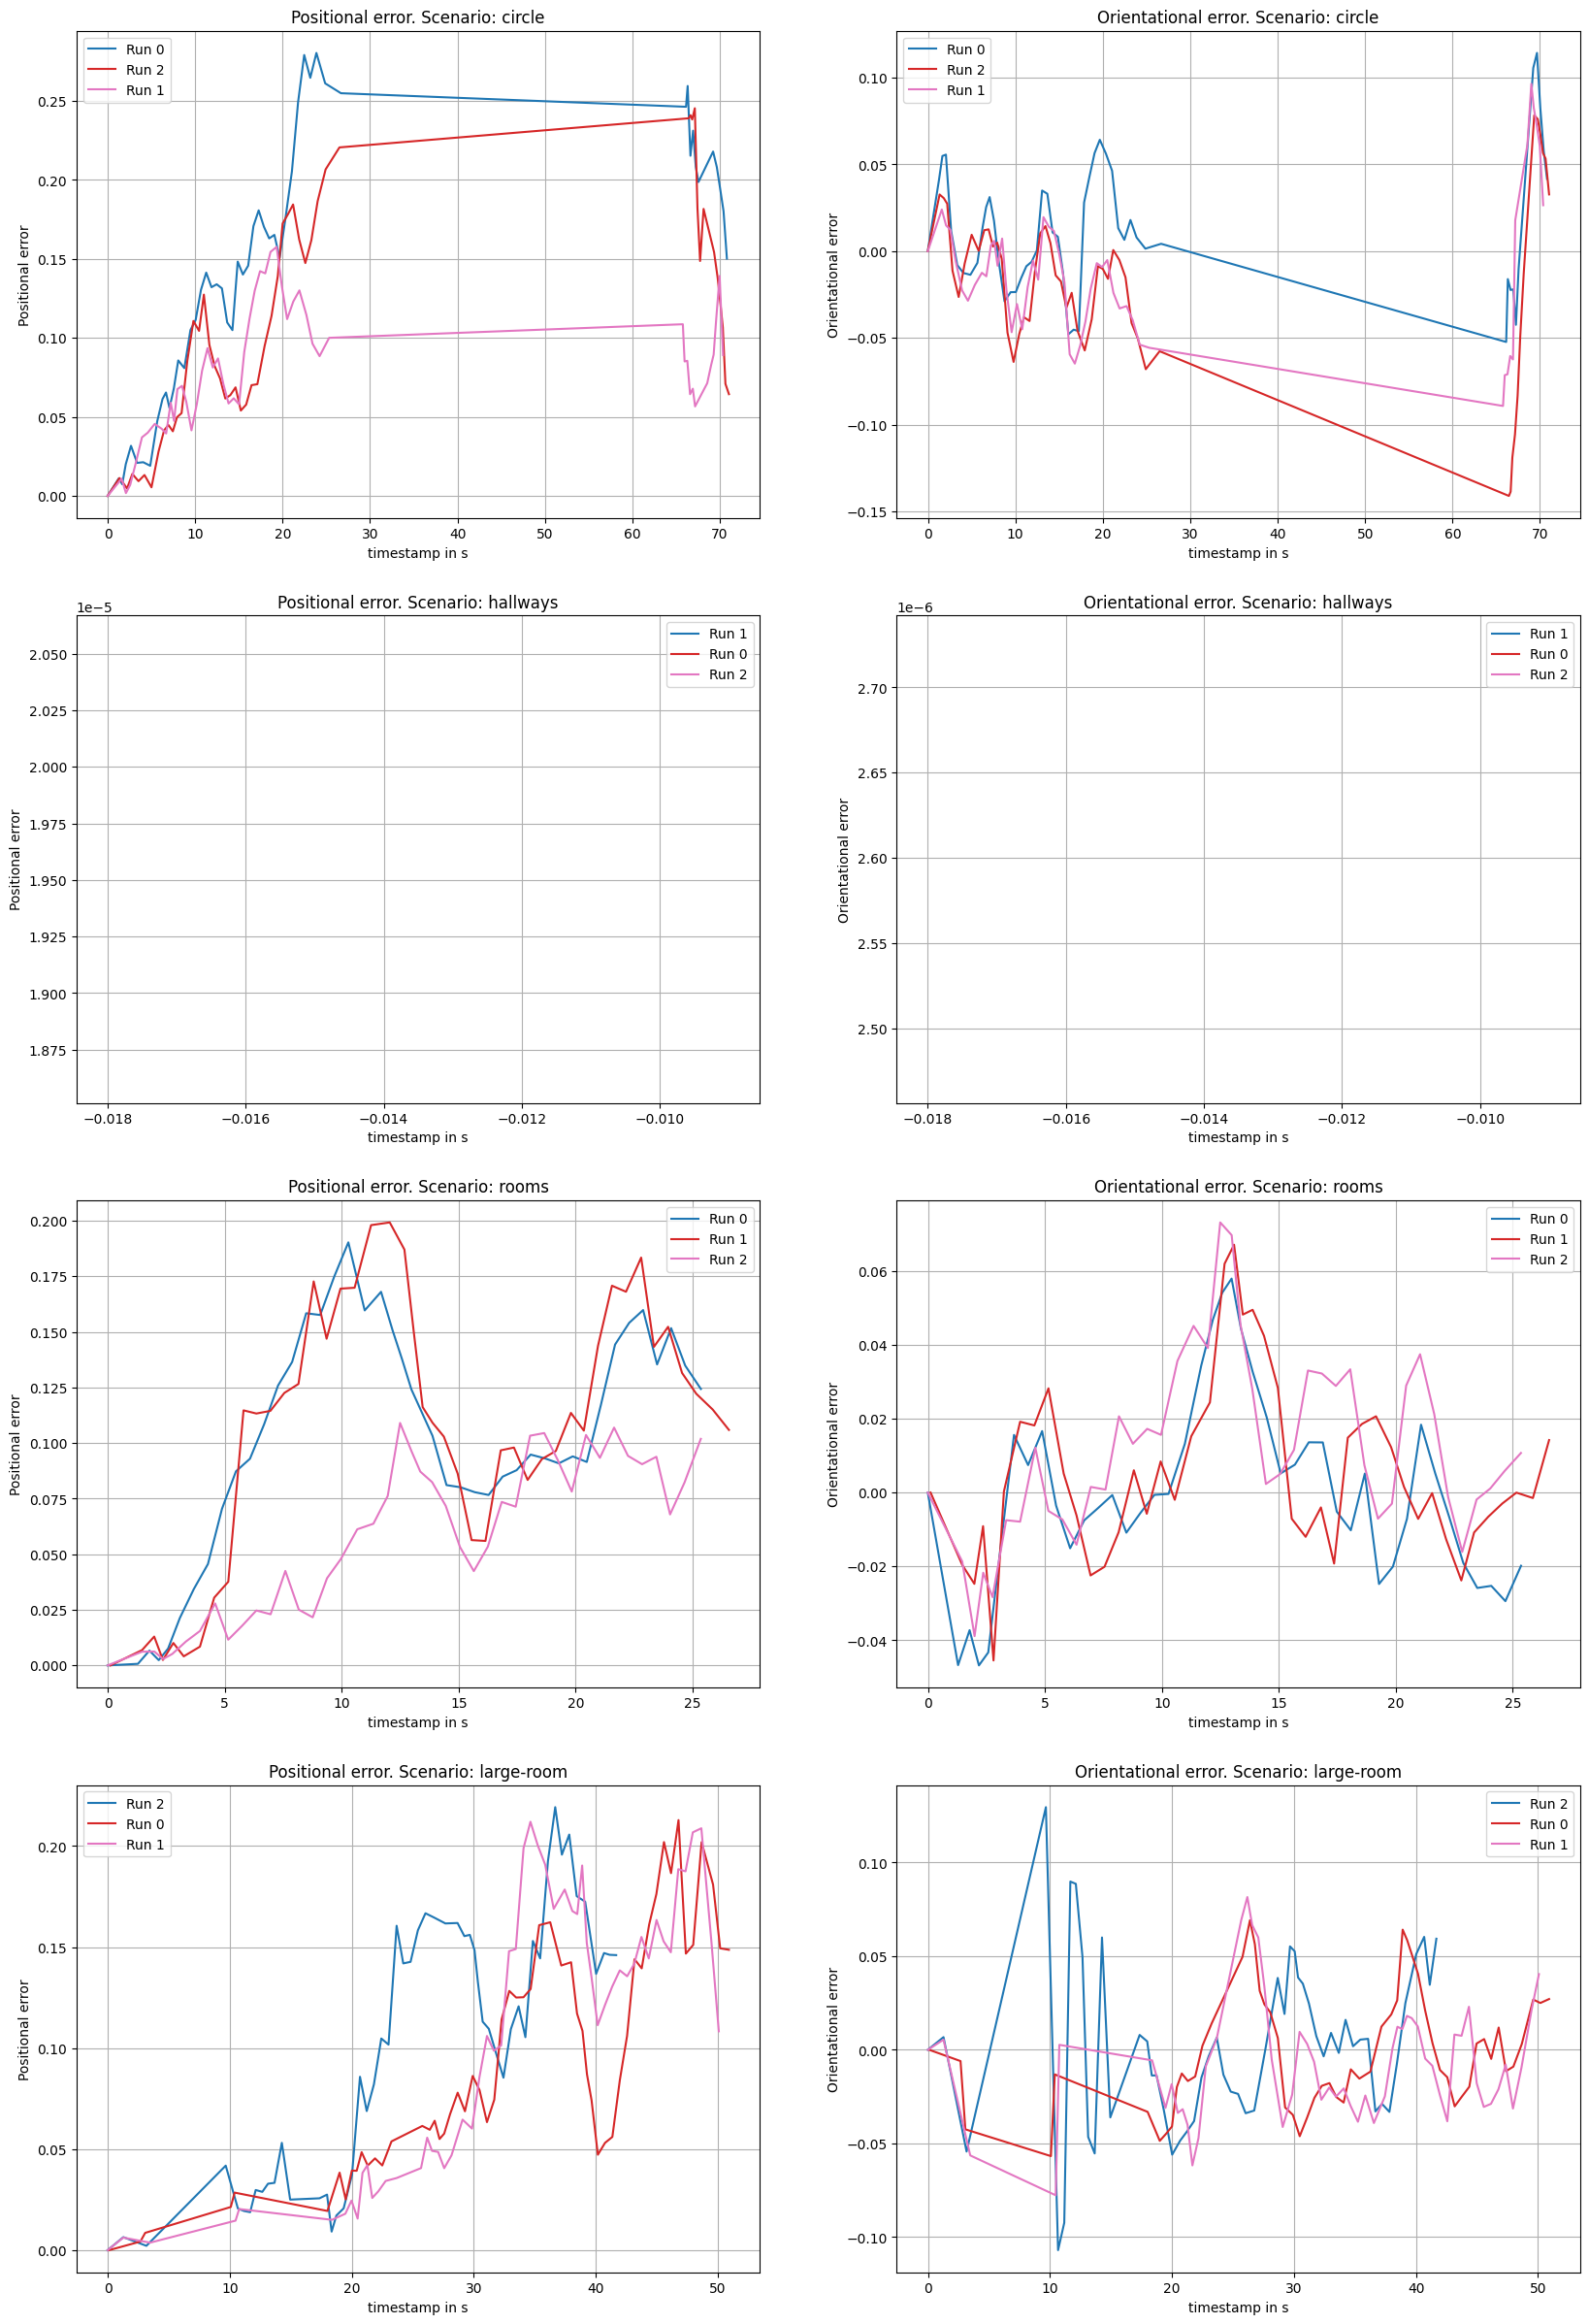

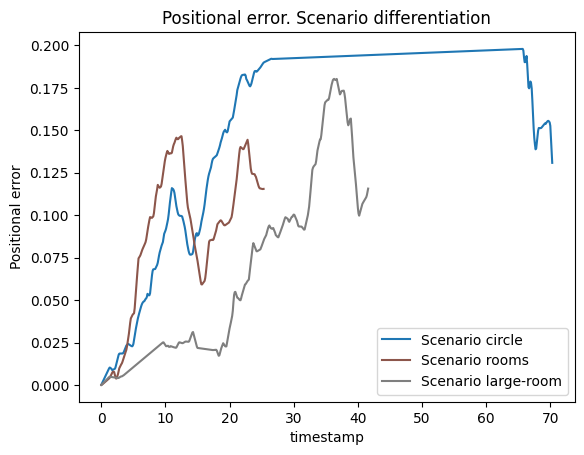

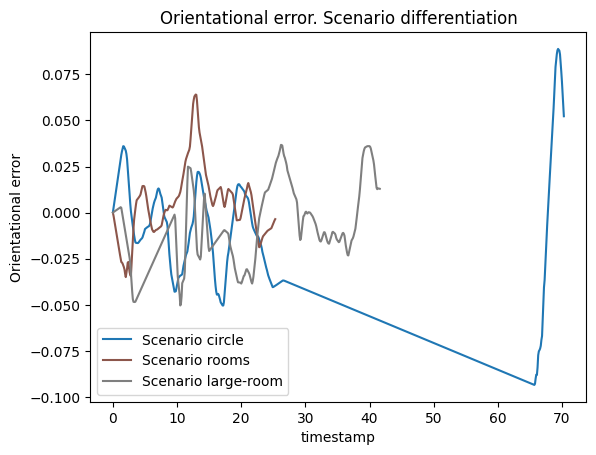

In [6]:
#Analysis of deduced pose with real pose (localization)

#figure for means position
plt.figure(0)
plt.title('Positional error. Scenario differentiation')
plt.xlabel(TIMESTAMP)
plt.ylabel('Positional error')
#figure for means orientation
plt.figure(1)
plt.title('Orientational error. Scenario differentiation')
plt.xlabel(TIMESTAMP)
plt.ylabel('Orientational error')

plt.figure(2)
fig, axes = plt.subplots(len(dataset), 2, figsize=(20, 30))

for i, scenario_group in enumerate(dataset):
    #figure for scenario position 
    axes[i, 0].set_title('Positional error. Scenario: ' +  scenario_group[0].scenario)
    axes[i, 0].set_xlabel(TIMESTAMP + " in s")
    axes[i, 0].set_ylabel('Positional error')
    #figure for scenario orientation
    axes[i, 1].set_title('Orientational error. Scenario: ' +  scenario_group[0].scenario)
    axes[i, 1].set_xlabel(TIMESTAMP + " in s")
    axes[i, 1].set_ylabel('Orientational error')

    # maximum time of all runs and scenarios
    t_max = []
    # sum of position and orientation error of the scenario
    position_error_sum = []
    yaw_error_sum = []
              
    for j, run in enumerate(scenario_group):
        t0 = run.df[TIMESTAMP].iloc[1]
        deduced_pose = run.df.loc[run.df[TOPIC] == AMCL_POSE]
        real_pose = run.df.loc[run.df[TOPIC] == GROUNDTRUTH_POSE]

        # get pose error
        position_error, yaw_error, timestamp = get_pose_error(deduced_pose, real_pose)
        ts = np.asarray(timestamp - t0, dtype=np.float64) 
        ts = ts / 1e9 # time in seconds

        # Plot the data of the run in scenario differentiation
        color = cmap(j / len(scenario_group) )
        axes[i, 0].plot(ts, position_error, color=color, label=f"Run {run.run_n}")
        axes[i, 1].plot(ts, yaw_error, color=color, label=f"Run {run.run_n}")   

        # mean of scenario:
        t_max.append(ts[-1])
        # array of time from 0 to max time each 0.1s to have common timeline
        t = np.arange(0, ts[-1], 0.1)
        position_error_sum.append(np.interp(t, ts, position_error))
        yaw_error_sum.append(np.interp(t, ts, yaw_error))

    axes[i, 0].grid()
    axes[i, 0].legend()
    axes[i, 1].grid()
    axes[i, 1].legend()
    
    # Differentiate scenarios. Mean is just possible like this if all runs 
    # finish moreless the same time.
    t_mean = np.mean(t_max)
    t_std = np.std(t_max)
    if (abs(t_std / t_mean) < 0.1):
        # Create the mean of the scenarios 
        min_len = min(len(position_error) for position_error in position_error_sum)
        position_error_sum = [position_error[:min_len] for position_error in position_error_sum]
        yaw_error_sum = [yaw_error[:min_len] for yaw_error in yaw_error_sum]
        
        position_error_mean = np.mean(np.vstack(position_error_sum), axis=0)
        yaw_error_mean = np.mean(np.vstack(yaw_error_sum), axis=0)
        
        #get array of time until there is data of all runs
        t = np.arange(0, np.min(t_max), 0.1)
        #Plot results
        color = cmap(i / len(dataset) )
        plt.figure(0)
        plt.plot(t, position_error_mean, color=color, label=f"Scenario {scenario_group[0].scenario}")

        plt.figure(1)
        plt.plot(t, yaw_error_mean, color=color, label=f"Scenario {scenario_group[0].scenario}")   
        
plt.figure(0)
plt.legend()
plt.figure(1)
plt.legend()
    

<Figure size 640x480 with 0 Axes>

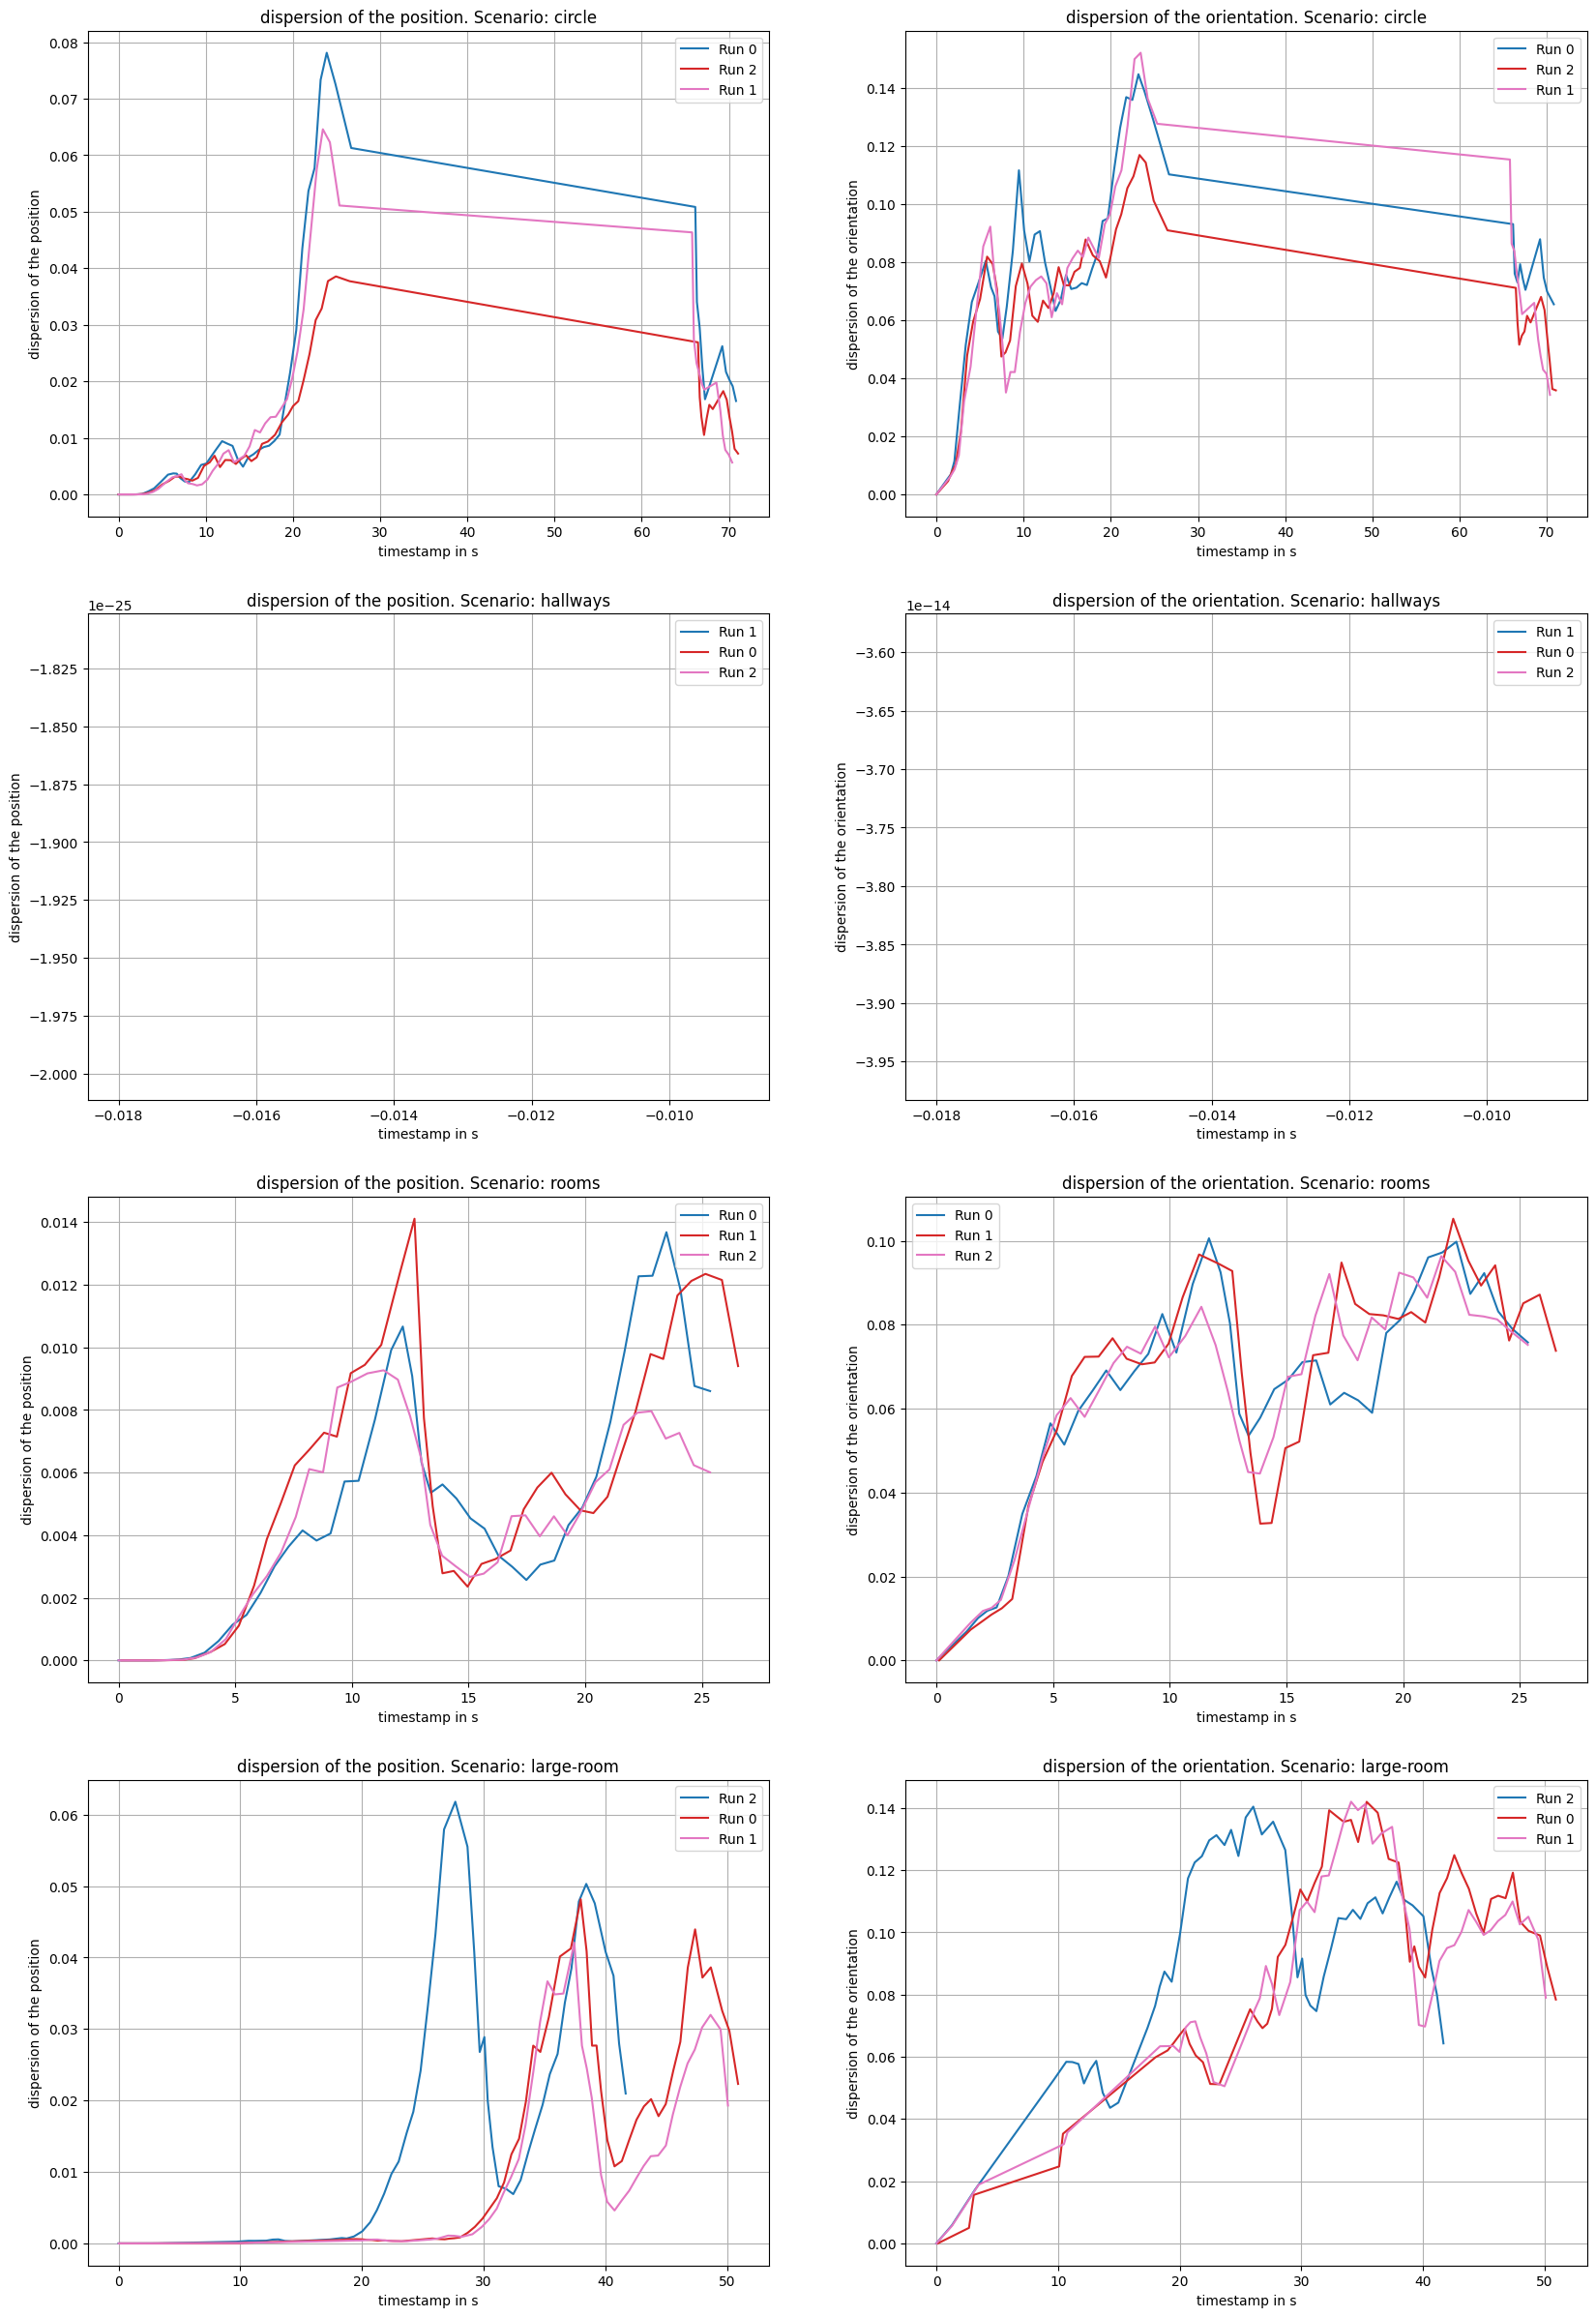

In [7]:
#Covariance analysis
#strong density equals small dispersion and good localization
#figure for means determinant covariance matrix

plt.figure(2)
fig, axes = plt.subplots(len(dataset), 2, figsize=(20, 30))

for i, scenario_group in enumerate(dataset):

    #figures for dispersion of the position and orientation
     
    axes[i, 0].set_title('dispersion of the position. Scenario: ' +  scenario_group[0].scenario)
    axes[i, 0].set_xlabel(TIMESTAMP + " in s")
    axes[i, 0].set_ylabel('dispersion of the position')
         
    axes[i, 1].set_title('dispersion of the orientation. Scenario: ' +  scenario_group[0].scenario)
    axes[i, 1].set_xlabel(TIMESTAMP + " in s")
    axes[i, 1].set_ylabel('dispersion of the orientation')
    
          
    for j, run in enumerate(scenario_group):
        t0 = run.df[TIMESTAMP].iloc[1]
        deduced_pose = run.df.loc[run.df[TOPIC] == AMCL_POSE]

        # get dispersion pose from covariance matrix
        disp_pos, disp_yaw, timestamp = get_disp_covariance(deduced_pose)
        ts = np.asarray(timestamp - t0, dtype=np.float64) 
        ts = ts / 1e9 # time in seconds

        # Plot the data of the run in scenario differentiation
        color = cmap(j / len(scenario_group) )
        axes[i, 0].plot(ts, disp_pos, color=color, label=f"Run {run.run_n}")

        axes[i, 1].plot(ts, disp_yaw, color=color, label=f"Run {run.run_n}")

    axes[i, 0].grid()
    axes[i, 0].legend()
    axes[i, 1].grid()
    axes[i, 1].legend()


### Scenario 1

In the first scenario, the graph shows how the robot’s localization error evolves over time.  
Initially, the error fluctuates until approximately **second 22**, where it becomes stable for a while before increasing again near the end of the run.

When compared with the dispersion data, a clear correlation is observed: around second 22, the dispersion increases sharply and remains high until the end.  
However, the position error does **not** increase during this period, indicating that despite a rise in uncertainty (lower confidence in localization), the **mean estimate remains close to the real position**.  
This behavior suggests that the localization system maintains good accuracy even when the confidence is low — a common situation when the robot moves through areas with similar geometric features that reduce the distinctiveness of LiDAR observations.

Additionally, small dispersion peaks can be observed when the robot encounters **local obstacles** not present in the map. These cause temporary inconsistencies between LiDAR readings and the known environment, resulting in transient uncertainty increases.

---

### Scenario 2

For the second scenario, **just one localization data were recorded**.  
No trayectory could be executed. The reason of this is discovered and explained in the logs analysis.

Because no trajectory could be executed, no localization or covariance data are available for analysis in this case.

---

### Scenario 3

In the third scenario, both the localization error and the dispersion increase steadily until approximately **second 15**, where they suddenly drop.  
This behavior corresponds to the robot reaching a **highly distinctive and identifiable position** within the map, allowing the localization system to recover its accuracy.

Although this map does not contain obstacles not represented in the map, the dispersion still increases gradually over time.  
This may be due to either:
- The **homogeneity of the environment**, where multiple regions share similar LiDAR features, or  
- **Sensor noise** in the LiDAR data.

To determine which factor dominates, additional sensor-level information would be required.

---

### Scenario 4

In the last scenario, clear peaks in both the **error** and **dispersion** can be observed simultaneously.  
Since there are no unmodeled obstacles, these peaks likely originate from either **localization ambiguity** in certain areas or **sensor issues**.

Given that the robot is located in unique regions of the map when these peaks occur, and the accompanying video evidence shows a temporary **misalignment between the LiDAR point cloud and the map** (appearing as if the LiDAR rotation drifts), the most plausible explanation is a **temporary LiDAR misreading** or **synchronization issue**.

To confirm this hypothesis, it would be necessary to directly compare the LiDAR scans with the expected global map data to check whether the deviation corresponds to sensor errors or environmental ambiguity. 

---


## Log Analysis

In addition to the localization and covariance data, the ROS2 log files were analyzed to extract useful information about the robot’s navigation performance and failure conditions.  
From the logs, several key messages were identified as indicators of specific navigation events:

- **`[INFO] [controller_server]: Passing new path to controller.`** — indicates that the planner has generated a new path and passed it to the controller. Frequent occurrences may suggest replanning events caused by dynamic obstacles or localization drift.  
- **`[ERROR] [controller_server]: Failed to make progress`** — signals that the controller could not advance toward the goal, usually because of navigation or localization problems.  
- **`[INFO] [bt_navigator]: Goal succeeded`** — confirms that the robot successfully reached the goal position.  
- **`[INFO] [bt_navigator]: Goal failed`** — indicates that the navigation task failed.  
- **`[INFO] [bt_navigator]: Begin navigating from current location through 1 poses to (x, y)`** — marks the start of the navigation process.  
- **`[WARN] [planner_server]: GridBased plugin failed to plan from (...) to (...): "Failed to create plan with tolerance of: 0.500000"`** — occurs when the planner is unable to find a valid path to the target position.

Using these messages, it is possible to extract and analyze several performance indicators for each run:

- Whether the robot **successfully reached the goal** or failed.  
- If the failure was caused by **the planner’s inability to generate a path**.  
- The **total time** taken to complete or fail the run (from start to goal).  
- The **number of path replanning events** triggered during the run.  
- The **number of controller failures** where progress could not be made.

---

In [8]:
#Process logs per scenario and run

pattern_br = r"\[(.*?)\]"

#Serch in the files of the scenario and run the logs files.
for scenario_group in dataset:
    scenario = scenario_group[0].scenario
    scenario_dir = glob.glob(DATASET_PATH + "/" + scenario + SCENARIO_SEP + "*")[0]
    for run in scenario_group:
        run_n = run.run_n
        #open log file component_container_isolated. Is the only one with important information to process
        logs_file = glob.glob(scenario_dir + "/" + str(run_n) + "/" + LOGS_DIR + "/" + LOG_CCI + "*")
        if os.path.isfile(logs_file[0]):
            with open(logs_file[0], "r") as f:
                for line in f:
                    # get strings between []
                    brakets = re.findall(pattern_br, line)
                    if len(brakets) == 3:
                        # log info are structured like [type] [time] [sender] : msg
                        type_msg = brakets[0]
                        time = float(brakets[1])
                        sender = brakets[2]
                        msg = line.split("]:")[-1].strip()
                        log = LogsRos(type_msg, time, sender, msg)
                        #Add log to the datasetRos object
                        run.add_log(log)

run  0  of scenario circle succeeded
run  2  of scenario circle succeeded
run  1  of scenario circle succeeded
run  1  of scenario hallways failed
reason:  GridBased plugin failed to plan from (4.01, 4.78) to (5.29, -5.01): "Failed to create plan with tolerance of: 0.500000"
run  0  of scenario hallways failed
reason:  GridBased plugin failed to plan from (4.01, 4.78) to (5.29, -5.01): "Failed to create plan with tolerance of: 0.500000"
run  2  of scenario hallways failed
reason:  GridBased plugin failed to plan from (4.01, 4.78) to (5.29, -5.01): "Failed to create plan with tolerance of: 0.500000"
run  0  of scenario rooms succeeded
run  1  of scenario rooms succeeded
run  2  of scenario rooms succeeded
run  2  of scenario large-room succeeded
run  0  of scenario large-room succeeded
run  1  of scenario large-room succeeded


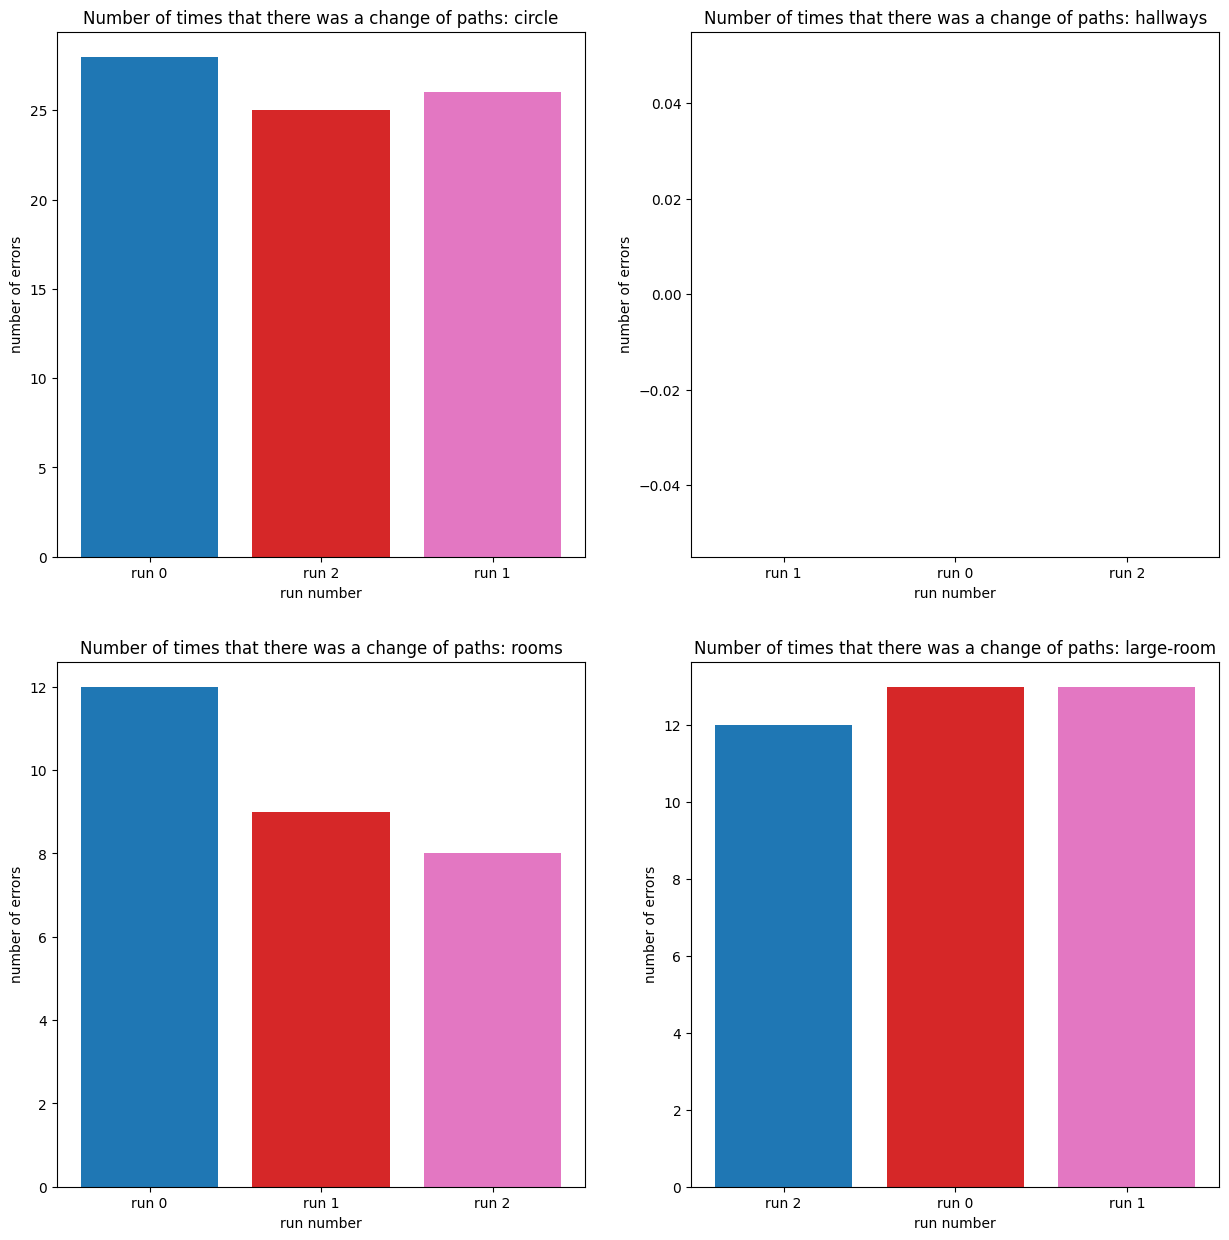

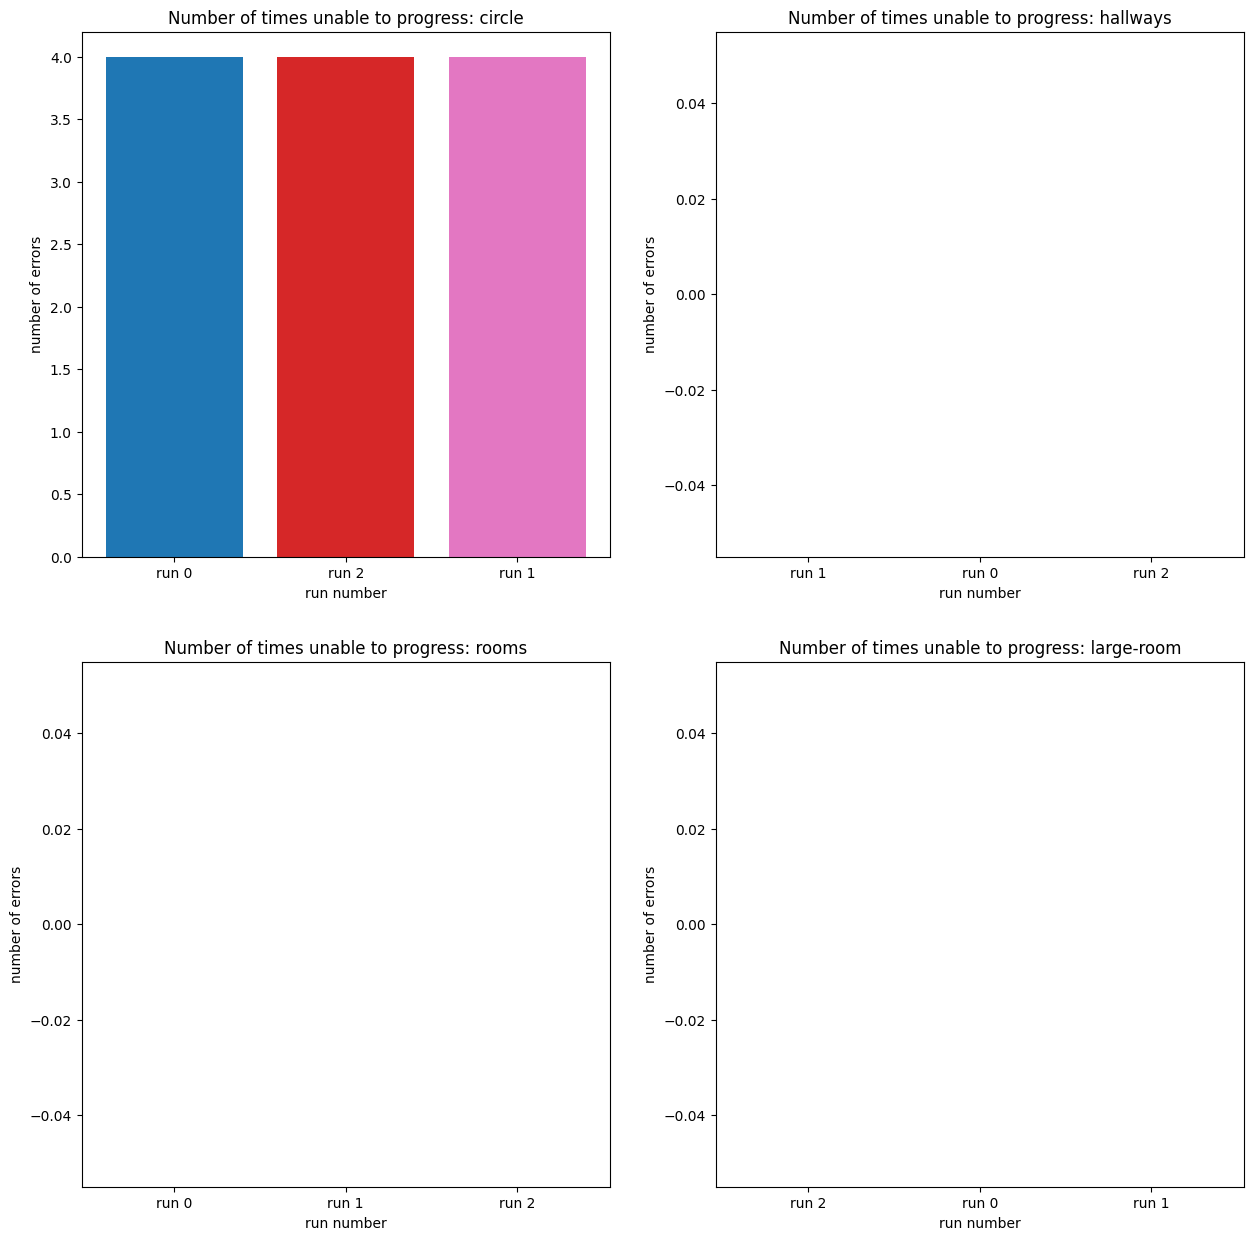

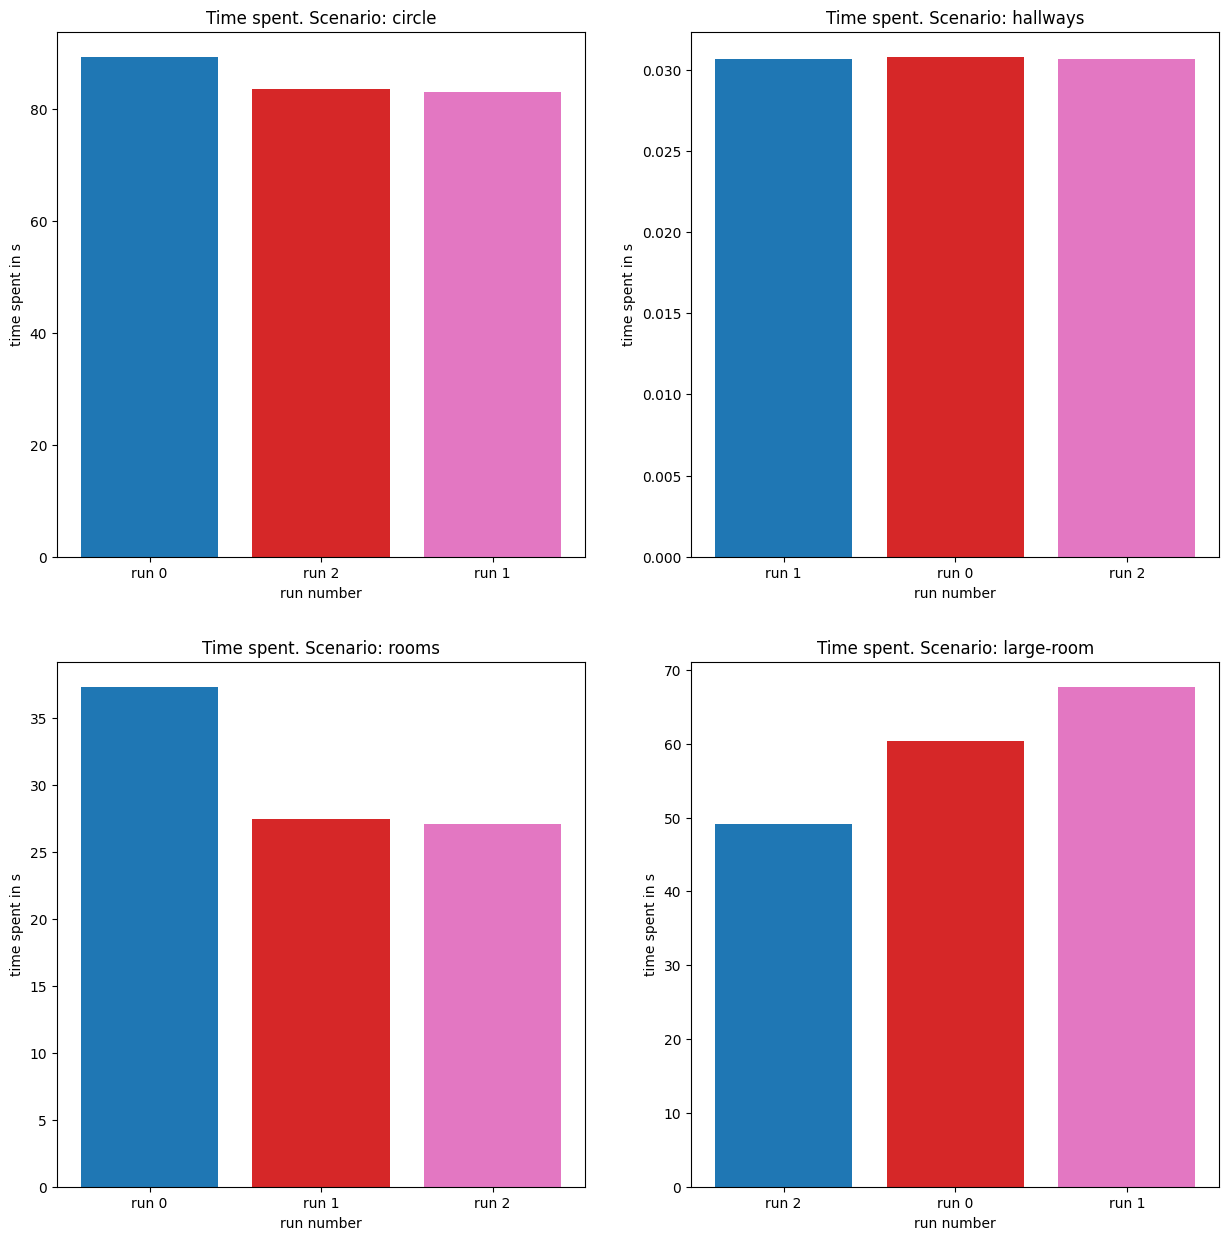

In [9]:
# Logs Analysis

#time spent figure
fig, axes_time = plt.subplots((len(dataset) + 1)//2, 2, figsize=(15, 15))
#changes of path
fig, axes_path = plt.subplots((len(dataset) + 1)//2, 2, figsize=(15, 15))
#unable to progress
fig, axes_prog = plt.subplots((len(dataset) + 1)//2, 2, figsize=(15, 15))

for i ,scenario_group in enumerate(dataset):

    axes_time[i // 2, i % 2].set_title('Time spent. Scenario: ' +  scenario_group[0].scenario)
    axes_time[i // 2, i % 2].set_ylabel('time spent in s')
    axes_time[i // 2, i % 2].set_xlabel('run number')

    axes_path[i // 2, i % 2].set_title('Number of times that there was a change of paths: ' +  scenario_group[0].scenario)
    axes_path[i // 2, i % 2].set_ylabel('number of errors')
    axes_path[i // 2, i % 2].set_xlabel('run number')

    axes_prog[i // 2, i % 2].set_title('Number of times unable to progress: ' +  scenario_group[0].scenario)
    axes_prog[i // 2, i % 2].set_ylabel('number of errors')
    axes_prog[i // 2, i % 2].set_xlabel('run number')
    
    run_name = []
    timespent = []
    err_path = []
    err_prog = []
    colors = []
    
    for j, run in enumerate(scenario_group):
        final_log = None
        #See if run succeeded or not
        if len(run.logs_failed) == 1:
            print("run ", run.run_n, " of scenario " + run.scenario + " failed")
            if len(run.logs_plan_f) > 0:
                print("reason: ", run.logs_plan_f[0].msg)
            else:
                print("reason: undefined")
            final_log = run.logs_failed[0]
        elif len(run.logs_success) == 1:
            print("run ", run.run_n, " of scenario " + run.scenario + " succeeded")
            final_log = run.logs_success[0]
        else :
            print("run ", run.run_n, " of scenario " + run.scenario + " undefined result")
            
        colors.append(cmap(j / len(scenario_group)))
        # See time spent from starting path to finishing
        if final_log != None and len(run.logs_begin) == 1:
            run_name.append("run " + str(run.run_n))
            timespent.append((final_log.time) - run.logs_begin[0].time)
        # Number of times that there was a change of paths
        err_path.append(len(run.logs_new_path))
        # Number of times unable to progress
        err_prog.append(len(run.logs_progress_f))

    plt.figure(1)
    axes_time[i // 2, i % 2].bar(run_name, timespent, color=colors)
    axes_path[i // 2, i % 2].bar(run_name, err_path, color=colors)
    axes_prog[i // 2, i % 2].bar(run_name, err_prog, color=colors)

### Observations by Scenario

- **Scenario 1:**  
  The logs show several *“Passing new path to controller”* events and a few *“Failed to make progress”* errors.  
  Despite these issues, the robot eventually reaches the goal, suggesting that the navigation system was able to recover from local problems.

- **Scenario 2:**  
  The run fails due to the *“GridBased plugin failed to plan”* error.  
  This indicates that the planner could not generate a feasible path to the goal, likely because of map or configuration constraints.

- **Scenarios 3 and 4:**  
  Both runs include several replanning events but no *“Failed to make progress”* errors.  
  The robot is able to continue moving toward the goal, showing that replanning was effective in these cases.

---


## Conclusions

Across all scenarios, the analysis of positional and orientational errors, together with covariance-based dispersion, provides valuable insight into the **stability and reliability of the Nav2 localization system**.  
The covariance determinant and yaw variance serve as effective indicators of uncertainty, complementing the error analysis by revealing moments of degraded localization confidence even when the average pose estimate remains accurate.
In addition, analysis of the ROS2 logs yielded important event-level information that complements the pose/covariance data.

### Limitations and requirements for stronger conclusions

1. **Time synchronization and alignment**  
   A critical limitation is the lack of a clear, consistent time reference across data sources. The system log timestamps appear tied to the host simulation/system time, whereas topic message timestamps (`/amcl_pose`, `/tf`, `/groundtruth_pose`) use a different time base. Because the exact relationship between these time domains is unknown (and it is not clear whether a real-time factor was applied), we cannot reliably align log events with CSV entries. Before making robust temporal correlations (for example, associating a `Failed to make progress` event with a spike in covariance or a drop in scan-to-map matching), it is necessary to determine:
   - what the topic timestamps actually represent (simulation time, ROS time, or system time),
   - the offset or mapping between topic timestamps and log timestamps, and
   - the true start time of each run (so that runs are consistently time-normalized).

2. **Comparability across scenarios**  
   Absolute error magnitudes and completion times are **not directly comparable between different scenarios** because each scenario has its own map geometry, obstacle layout, and goal positions. Therefore, meaningful comparisons should be restricted to **runs within the same scenario**. Cross-scenario comparisons must be normalized for map complexity, route length, and task difficulty to avoid misleading conclusions.

3. **LiDAR scan data is required**  
   To determine whether localization error spikes are caused by sensor anomalies or by map/environment ambiguity, the raw LiDAR scans must be included in the analysis. Note that there is a **single LiDAR data stream**: the ROS2 topic `/scan_sim` (`sensor_msgs/msg/LaserScan`) is the ROS-facing topic, which is bridged/forwarded with the simulator topic `/scan` (`gz.msgs.LaserScan`). For our analysis we should therefore ensure we extract the `/scan_sim` recordings (or confirm and extract the bridged `/scan` messages) so that scan-to-map matching metrics, ICP residuals, and visual inspection of anomalous scans can be performed. 

### Recommended next steps

- **Resolve time references**: clarify the meaning of topic timestamps and their relation to system logs; determine the true start time of every run. This is a prerequisite for any time-aligned correlation study.  
- **Enrich dataset with LiDAR scans**: include `/scan` and `/scan_sim` data so scan-to-map quality metrics can be computed and correlated with localization/covariance spikes and log events.  
- **Compute log-derived run metrics**: extract per-run features from logs (goal reached flag, planner-failure flag, number of replans, number of controller `Failed to make progress` events, run duration). Store these alongside pose/covariance summaries (e.g., mean_pos_error, mean_cov_det).  
- **Restrict comparisons**: perform statistical comparisons and scoring only among runs of the same scenario (or normalize metrics by scenario-specific factors before cross-scenario aggregation).  
- **Implement RunScore and failure classifier**: combine pose/covariance statistics and log-derived indicators into a single RunScore and define thresholds/rules to flag failed or degraded runs. This will facilitate automatic triage of large experiment sets.  
- **Correlate events**: once timestamps are synchronized, plot error and dispersion time series with markers for log events (replans, controller failures, planner failures, goal success/failure) and compute correlation / cross-correlation metrics to quantify event–error relationships.

By addressing the time-synchronization issue and adding raw LiDAR data to the dataset, the combined pose/covariance/log analysis will be able to move from qualitative observations to quantitative, reproducible conclusions about the causes of localization failures and navigation breakdowns.